In [17]:
import tensorflow as tf
print(tf.__version__)

2.21.0


# **Pneumonia Detection**

## **Importing Libraries**

In [18]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from PIL import Image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras import layers, models
from tensorflow.keras.models import Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation
from tensorflow.keras.layers import MaxPooling2D, GlobalAveragePooling2D
from tensorflow.keras.layers import Dense, Dropout

In [19]:
import random
random.seed(0)
import numpy as np
np.random.seed(0)
import tensorflow as tf
tf.random.set_seed(0)

## 
**Data Collection**

In [20]:
# dataset paths
train_df = r"C:\Users\Niharika rawat\OneDrive\Desktop\dataset\chest_xray\train"
test_df = r"C:\Users\Niharika rawat\OneDrive\Desktop\dataset\chest_xray\test"
val_df = r"C:\Users\Niharika rawat\OneDrive\Desktop\dataset\chest_xray\val"

# verify dataset structure
print("Train classes:", os.listdir(train_df))
print("Test classes:", os.listdir(test_df))
print("Validation classes:", os.listdir(val_df))

Train classes: ['NORMAL', 'PNEUMONIA']
Test classes: ['NORMAL', 'PNEUMONIA']
Validation classes: ['NORMAL', 'PNEUMONIA']


## **EDA**

### **Dataframe Creation** 

In [5]:
path = r'C:\Users\Niharika rawat\OneDrive\Desktop\dataset\chest_xray'
image_path_dict = {}  # Create image path dictionary

for split in ['train', 'test', 'val']:
    split_path = os.path.join(path, split)

    for root, dirs, files in os.walk(split_path):
        for f in files:
            if f.lower().endswith('.jpeg'):
                full_path = os.path.join(root, f)
                image_path_dict[f] = full_path

print("Total images:",len(image_path_dict))

Total images: 5856


In [6]:
pneu_df = pd.DataFrame(list(image_path_dict.items()),columns=['image_name', 'image_path'])

pneu_df.head()
pneu_df.shape


(5856, 2)

In [7]:
pneu_df['image_path'].iloc[0]

'C:\\Users\\Niharika rawat\\OneDrive\\Desktop\\dataset\\chest_xray\\train\\NORMAL\\IM-0115-0001.jpeg'

In [8]:
print("Rows:", len(pneu_df))
print("Unique paths:", pneu_df['image_path'].nunique())
print("Duplicate paths:", pneu_df['image_path'].duplicated().sum())

Rows: 5856
Unique paths: 5856
Duplicate paths: 0


In [9]:
print(pneu_df.columns)

Index(['image_name', 'image_path'], dtype='object')


In [10]:
pneu_df

,image_name,image_path
0,IM-0115-0001.jpeg,C:\Users\Niharika rawat\OneDrive\Desktop\datas...
1,IM-0117-0001.jpeg,C:\Users\Niharika rawat\OneDrive\Desktop\datas...
2,IM-0119-0001.jpeg,C:\Users\Niharika rawat\OneDrive\Desktop\datas...
3,IM-0122-0001.jpeg,C:\Users\Niharika rawat\OneDrive\Desktop\datas...
4,IM-0125-0001.jpeg,C:\Users\Niharika rawat\OneDrive\Desktop\datas...
...,...,...
5851,person1949_bacteria_4880.jpeg,C:\Users\Niharika rawat\OneDrive\Desktop\datas...
5852,person1950_bacteria_4881.jpeg,C:\Users\Niharika rawat\OneDrive\Desktop\datas...
5853,person1951_bacteria_4882.jpeg,C:\Users\Niharika rawat\OneDrive\Desktop\datas...
5854,person1952_bacteria_4883.jpeg,C:\Users\Niharika rawat\OneDrive\Desktop\datas...


In [11]:
pneu_df['label'] = pneu_df['image_path'].apply(lambda x:1 if 'PNEUMONIA' in x else 0)  #labeling

### **Class Distribution**

In [12]:
pneu_df['label'].value_counts()

label
1    4273
0    1583
Name: count, dtype: int64

In [13]:
pneu_df.tail()

,image_name,image_path,label
5851,person1949_bacteria_4880.jpeg,C:\Users\Niharika rawat\OneDrive\Desktop\datas...,1
5852,person1950_bacteria_4881.jpeg,C:\Users\Niharika rawat\OneDrive\Desktop\datas...,1
5853,person1951_bacteria_4882.jpeg,C:\Users\Niharika rawat\OneDrive\Desktop\datas...,1
5854,person1952_bacteria_4883.jpeg,C:\Users\Niharika rawat\OneDrive\Desktop\datas...,1
5855,person1954_bacteria_4886.jpeg,C:\Users\Niharika rawat\OneDrive\Desktop\datas...,1


### **Plot Distribution**

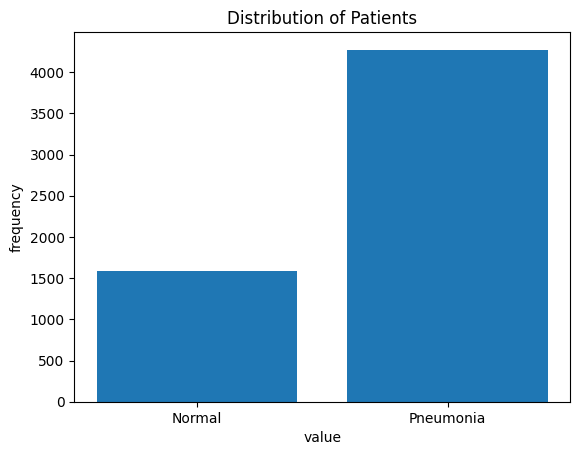

In [14]:
data = pneu_df['label'].value_counts()

plt.bar(data.index, data.values)

plt.xlabel("value")
plt.ylabel("frequency")
plt.title("Distribution of Patients")
plt.xticks([0, 1], ["Normal", "Pneumonia"])
plt.show()

### **Sample Images**  

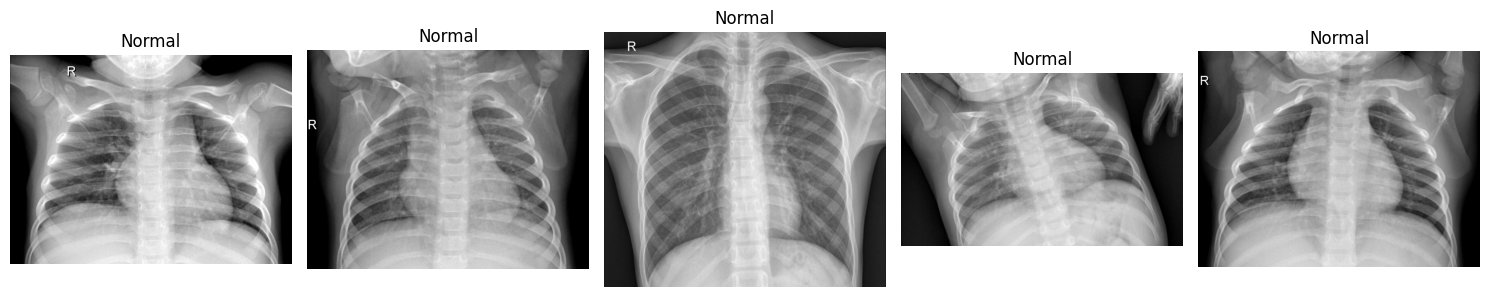

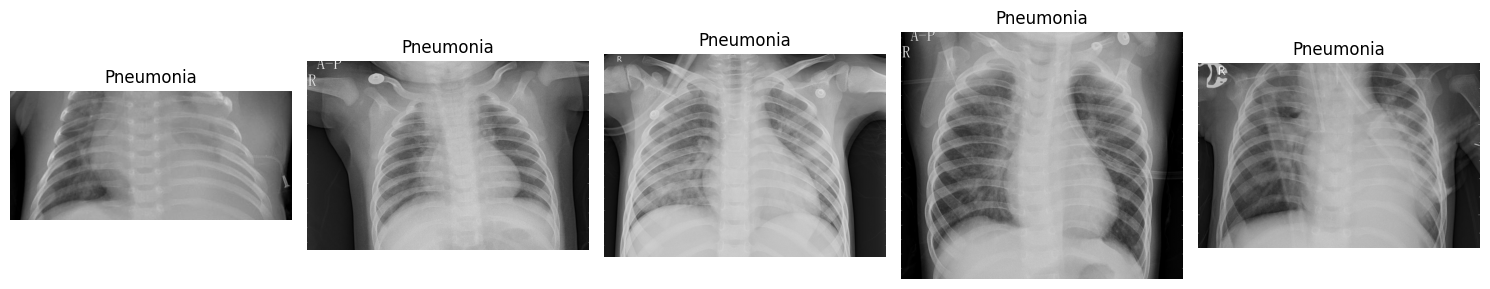

In [16]:
normal_images = pneu_df[pneu_df['label']==0]['image_path'].sample(5, random_state=42)
pneumonia_images = pneu_df[pneu_df['label']==1]['image_path'].sample(5, random_state=42)

plt.figure(figsize=(15, 5))
for i, img_path in enumerate(normal_images):
    img = Image.open(img_path)

    plt.subplot(1, 5, i + 1)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.title('Normal')

plt.tight_layout()
plt.show()


plt.figure(figsize=(15, 5))
for i, img_path in enumerate(pneumonia_images):
    img = Image.open(img_path)

    plt.subplot(1, 5, i + 1)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.title('Pneumonia')

plt.tight_layout()
plt.show()